## Data Analysis of Meta (META) Stock

### 1. Prepare Your Data

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as web
import datetime as dt

#### Load the Stock Price Dataset into a Pandas DataFrame

In [37]:
meta_df=pd.read_csv("/content/META.csv")
display(meta_df.head())

,Date,Close,High,Low,Open,Volume
0,2012-05-18,37.995762,44.724282,37.767172,41.792356,573576400
1,2012-05-21,33.821495,36.435382,32.797807,36.306177,168192700
2,2012-05-22,30.810066,33.384198,30.750434,32.410203,101786600
3,2012-05-23,31.803938,32.300874,31.167860,31.177799,73600000
4,2012-05-24,32.827625,33.006523,31.575347,32.748117,50237200


#### Ensure Columns are Correctly Typed

In [38]:
meta_df['Date'] = pd.to_datetime(meta_df['Date'])
meta_df =meta_df.set_index('Date')

#### Check for and Handle Missing Values

In [39]:
print('DataFrame Info:')
meta_df.info()

print('\nMissing values in each column:')
display(meta_df.isnull().sum())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2923 entries, 2012-05-18 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2923 non-null   float64
 1   High    2923 non-null   float64
 2   Low     2923 non-null   float64
 3   Open    2923 non-null   float64
 4   Volume  2923 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 137.0 KB

Missing values in each column:


,0
Close,0
High,0
Low,0
Open,0
Volume,0


As confirmed above, there are no missing values in our dataset, so no further handling is required at this stage.

### 2. Compute Technical Indicators with TA-Lib

In [ ]:
!pip install TA-Lib

#### Calculate Moving Averages (SMA, EMA), Relative Strength Index (RSI), and MACD

In [40]:
!pip install TA-Lib
import talib

meta_df['SMA_10'] = talib.SMA(meta_df['Close'], timeperiod=10)
meta_df['SMA_30'] = talib.SMA(meta_df['Close'], timeperiod=30)

meta_df['EMA_10'] = talib.EMA(meta_df['Close'], timeperiod=10)
meta_df['EMA_30'] = talib.EMA(meta_df['Close'], timeperiod=30)

meta_df['RSI'] = talib.RSI(meta_df['Close'], timeperiod=14)

macd, macdsignal, macdhist = talib.MACD(meta_df['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
meta_df['MACD'] = macd
meta_df['MACD_Signal'] = macdsignal
meta_df['MACD_Hist'] = macdhist

display(meta_df.tail())

,Close,High,Low,Open,Volume,SMA_10,SMA_30,EMA_10,EMA_30,RSI,MACD,MACD_Signal,MACD_Hist
Date,,,,,,,,,,,,,
2023-12-22,351.224823,355.011477,349.068105,353.401377,11772800,339.315216,332.613203,341.629442,331.635315,67.333885,6.945367,4.729907,2.215461
2023-12-26,352.655975,354.792827,351.284456,352.814999,9898600,342.252112,333.476546,343.634266,332.991487,68.187000,7.436800,5.271285,2.165514
2023-12-27,355.637543,356.800387,353.132994,353.888347,13207900,344.598642,334.425363,345.816680,334.452523,69.947874,7.974921,5.812012,2.162908
2023-12-28,356.124634,359.682686,355.617749,357.496184,11798800,346.942197,335.154536,347.690854,335.850723,70.237702,8.344500,6.318510,2.025990
2023-12-29,351.791290,357.794292,349.664418,356.790470,14987100,349.008456,335.858529,348.436388,336.879147,64.296803,8.193282,6.693464,1.499818


### Insights on Calculated Technical Indicators:

These technical indicators are crucial tools for understanding Meta's (META) stock price movements and making informed trading or investment decisions:

1.  **Simple Moving Averages (SMA_10, SMA_30)**:
    *   **Purpose**: SMAs smooth out price data to identify the direction of the trend, reducing the impact of random short-term fluctuations. The `SMA_10` represents a short-term trend, while `SMA_30` shows a medium-term trend.
    *   **Insight**: When the shorter-term SMA (e.g., SMA_10) crosses above the longer-term SMA (e.g., SMA_30), it's often considered a bullish signal, suggesting an upward trend is forming. Conversely, a crossover below is a bearish signal. These crossovers provide potential buy or sell signals.

2.  **Exponential Moving Averages (EMA_10, EMA_30)**:
    *   **Purpose**: EMAs are similar to SMAs but give more weight to recent prices, making them more responsive to new information and price changes. Like SMAs, they help identify trend direction.
    *   **Insight**: Because EMAs react faster to price changes, they can provide earlier signals than SMAs, which can be advantageous in fast-moving markets. Crossovers between different EMA periods (e.g., EMA_10 and EMA_30) are also used as trend-following indicators, similar to SMAs but with increased sensitivity.

3.  **Relative Strength Index (RSI)**:
    *   **Purpose**: RSI is a momentum oscillator that measures the speed and change of price movements. It ranges from 0 to 100.
    *   **Insight**: An RSI value typically above 70 indicates that the stock is becoming overbought, suggesting it may be due for a price correction or a downward trend reversal. An RSI below 30 suggests the stock is oversold, potentially indicating an upcoming upward trend reversal. It helps identify potential turning points in price action.

4.  **Moving Average Convergence Divergence (MACD, MACD_Signal, MACD_Hist)**:
    *   **Purpose**: MACD is a trend-following momentum indicator that shows the relationship between two moving averages of a security’s price. It consists of the MACD line, a signal line, and a histogram.
    *   **Insight**: A bullish signal occurs when the MACD line crosses above the signal line (often accompanied by a positive MACD Histogram). A bearish signal is generated when the MACD line crosses below the signal line (with a negative MACD Histogram). The histogram itself shows the difference between the MACD and signal lines, indicating the strength of momentum. Divergences between MACD and price can also signal potential trend reversals.

### 3. Apply PyNance for Financial Metrics

In [ ]:
!pip install pynance

#### Understanding PyNance and Calculating Additional Metrics

While `TA-Lib` is excellent for calculating a wide array of technical indicators (like SMA, RSI, MACD), `PyNance` is a broader financial analysis framework. It focuses on object-oriented representations of financial instruments (like stocks), portfolios, and provides tools for tasks such as valuation, risk management, and constructing financial models rather than just adding indicator columns to a DataFrame.

For calculating additional *metrics* that extend beyond typical technical indicators but are often used in financial analysis, we can leverage pandas. Below, we will calculate **Daily Returns** and **Historical Volatility** for the Google stock.

In [41]:
meta_df['Daily_Return'] = meta_df['Close'].pct_change() * 100

meta_df['Volatility_20_Day'] = meta_df['Daily_Return'].rolling(window=20).std()

display(meta_df.tail())

,Close,High,Low,Open,Volume,SMA_10,SMA_30,EMA_10,EMA_30,RSI,MACD,MACD_Signal,MACD_Hist,Daily_Return,Volatility_20_Day
Date,,,,,,,,,,,,,,,
2023-12-22,351.224823,355.011477,349.068105,353.401377,11772800,339.315216,332.613203,341.629442,331.635315,67.333885,6.945367,4.729907,2.215461,-0.197681,1.608984
2023-12-26,352.655975,354.792827,351.284456,352.814999,9898600,342.252112,333.476546,343.634266,332.991487,68.187000,7.436800,5.271285,2.165514,0.407475,1.580919
2023-12-27,355.637543,356.800387,353.132994,353.888347,13207900,344.598642,334.425363,345.816680,334.452523,69.947874,7.974921,5.812012,2.162908,0.845461,1.569692
2023-12-28,356.124634,359.682686,355.617749,357.496184,11798800,346.942197,335.154536,347.690854,335.850723,70.237702,8.344500,6.318510,2.025990,0.136963,1.475835
2023-12-29,351.791290,357.794292,349.664418,356.790470,14987100,349.008456,335.858529,348.436388,336.879147,64.296803,8.193282,6.693464,1.499818,-1.216805,1.456609


### Understanding the Financial Metrics: Deeper Insights

1.  **Daily Returns (`meta_df['Daily_Return']`)**:
    *   **What it is**: This metric quantifies the percentage change in Meta's stock price from one closing day to the next. It's calculated by `(Current_Close - Previous_Close) / Previous_Close * 100`.
    *   **Why it's important**: Daily returns are the most fundamental measure of a stock's performance. They directly indicate the profit or loss an investor would realize on a daily basis. Analyzing daily returns helps identify short-term price movements, assess market reactions to news, and forms the basis for more complex risk and return calculations. Positive returns signal growth, while negative returns indicate a decline.
    *   **Insight**: Consistent positive daily returns, even small ones, compound significantly over time. Conversely, large negative returns can quickly erode capital. Understanding the distribution and frequency of these returns is crucial for risk management and portfolio construction.

2.  **Historical Volatility (`meta_df['Volatility_20_Day']`)**:
    *   **What it is**: This metric measures the *dispersion* or *spread* of the daily returns over a specified period, in this case, a 20-day rolling window. It's calculated as the standard deviation of the daily returns within that window.
    *   **Why it's important**: Volatility is a key indicator of **risk**. A higher volatility means the stock price experiences larger and more frequent fluctuations, implying greater uncertainty and potential for both larger gains and larger losses. Conversely, lower volatility suggests a more stable and predictable price movement.
    *   **Insight**: For traders, high volatility can present more opportunities for short-term profits but also carries higher risk. For long-term investors, extreme volatility might be a concern as it indicates potential for significant drawdowns. The 20-day period is a common choice for assessing short-to-medium term price instability, helping to understand the recent 'choppiness' of the stock.

### 4. Visualize the Data

These plots illustrate the relationship between META's price action and various technical indicators, providing a visual understanding of market trends, momentum, and volatility.

#### Plot Closing Prices Overlaid with Moving Averages

##### META Close Price with Simple Moving Averages - Standalone

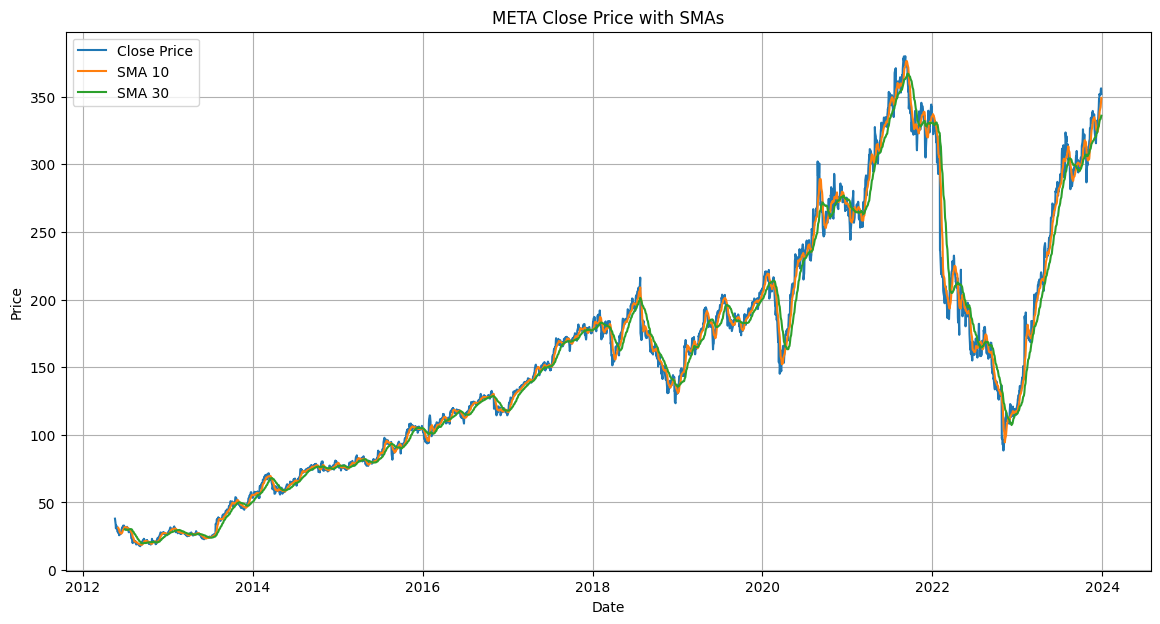

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(meta_df['Close'], label='Close Price')
plt.plot(meta_df['SMA_10'], label='SMA 10')
plt.plot(meta_df['SMA_30'], label='SMA 30')
plt.title('META Close Price with SMAs')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

##### META Close Price with Simple and Exponential Moving Averages - Standalone

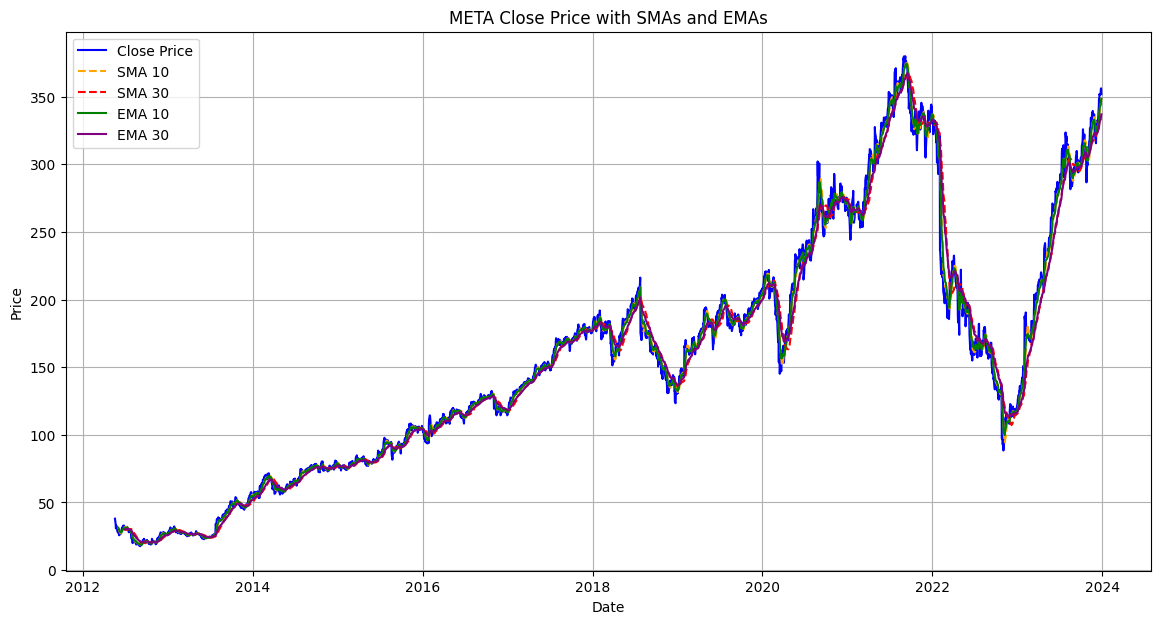

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(meta_df['Close'], label='Close Price', color='blue')
plt.plot(meta_df['SMA_10'], label='SMA 10', color='orange', linestyle='--')
plt.plot(meta_df['SMA_30'], label='SMA 30', color='red', linestyle='--')
plt.plot(meta_df['EMA_10'], label='EMA 10', color='green')
plt.plot(meta_df['EMA_30'], label='EMA 30', color='purple')
plt.title('META Close Price with SMAs and EMAs')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

#### Plot RSI and MACD in Separate Panels showing relation to Price Action

##### Combined Plot: META Close Price with Relative Strength Index (RSI)

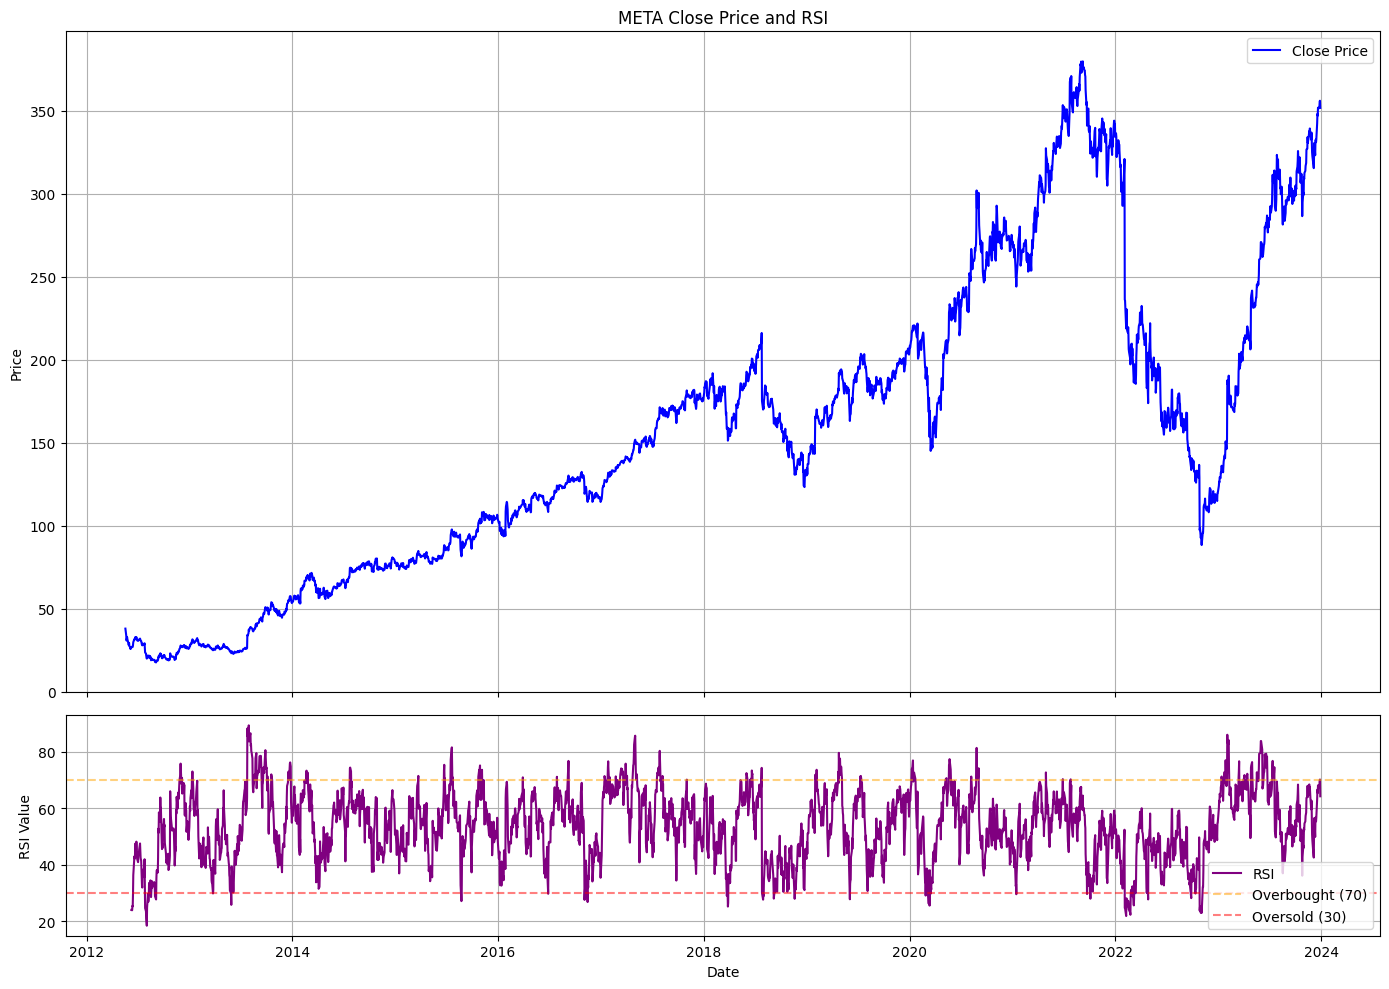

In [50]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot Close Price on the first subplot
ax1.plot(meta_df['Close'], label='Close Price', color='blue')
ax1.set_ylabel('Price')
ax1.set_title('META Close Price and RSI')
ax1.legend()
ax1.grid(True)

# Plot RSI on the second subplot
ax2.plot(meta_df['RSI'], label='RSI', color='purple')
ax2.axhline(70, linestyle='--', alpha=0.5, color='orange', label='Overbought (70)')
ax2.axhline(30, linestyle='--', alpha=0.5, color='red', label='Oversold (30)')
ax2.set_xlabel('Date')
ax2.set_ylabel('RSI Value')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

##### Combined Plot: META Close Price with Moving Average Convergence Divergence (MACD)

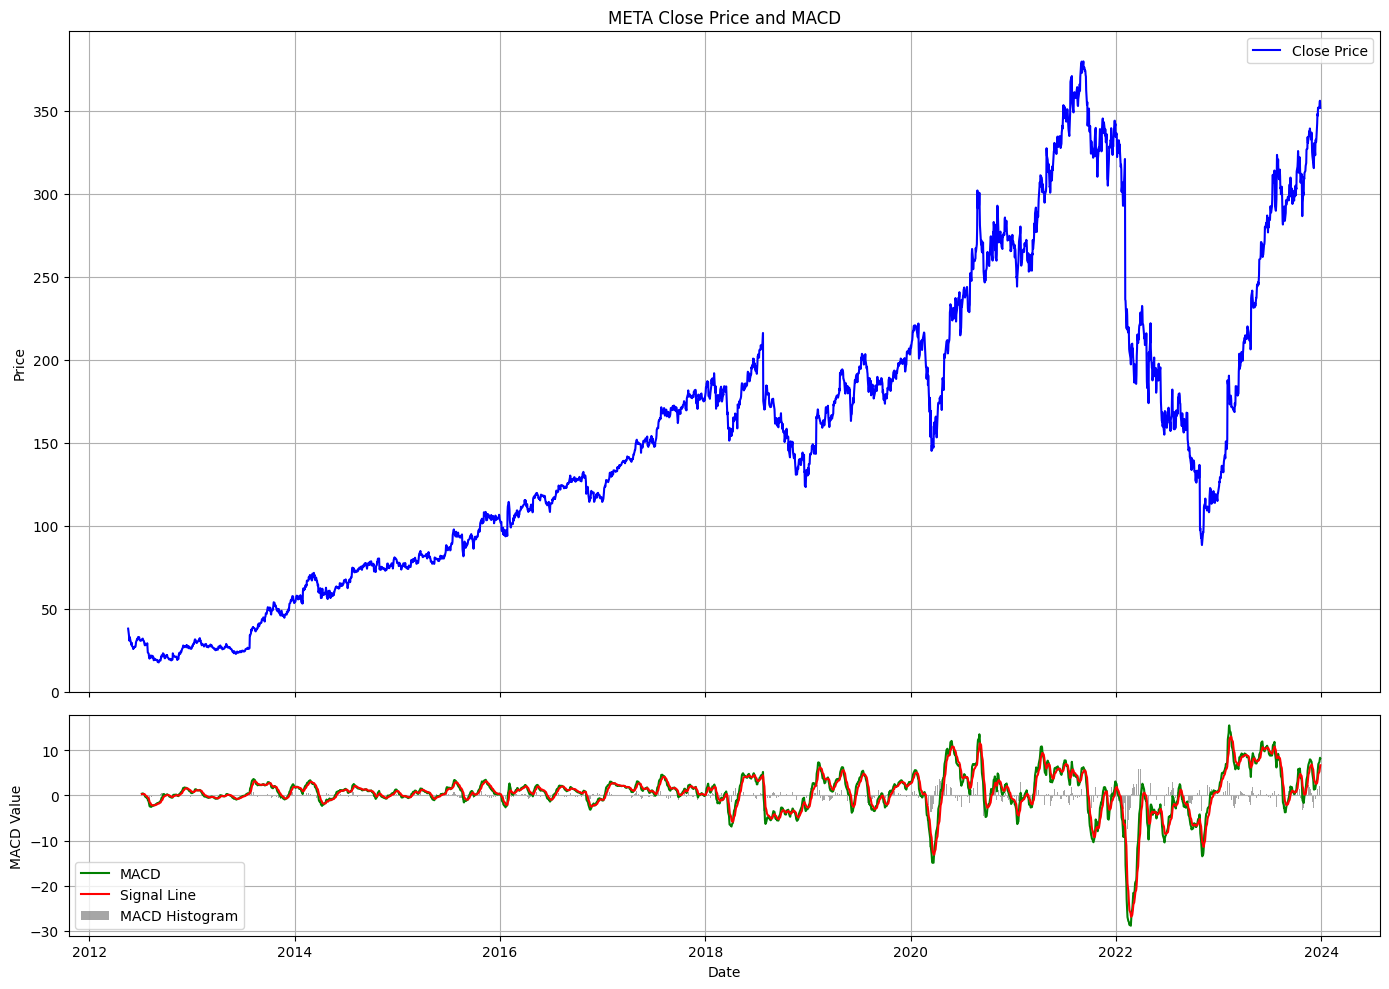

In [51]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Plot Close Price on the first subplot
ax1.plot(meta_df['Close'], label='Close Price', color='blue')
ax1.set_ylabel('Price')
ax1.set_title('META Close Price and MACD')
ax1.legend()
ax1.grid(True)

# Plot MACD on the second subplot
ax2.plot(meta_df['MACD'], label='MACD', color='green')
ax2.plot(meta_df['MACD_Signal'], label='Signal Line', color='red')
ax2.bar(meta_df.index, meta_df['MACD_Hist'], label='MACD Histogram', color='gray', alpha=0.7)
ax2.set_xlabel('Date')
ax2.set_ylabel('MACD Value')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

##### META: Multi-Panel Visualization (Price, RSI, and MACD)

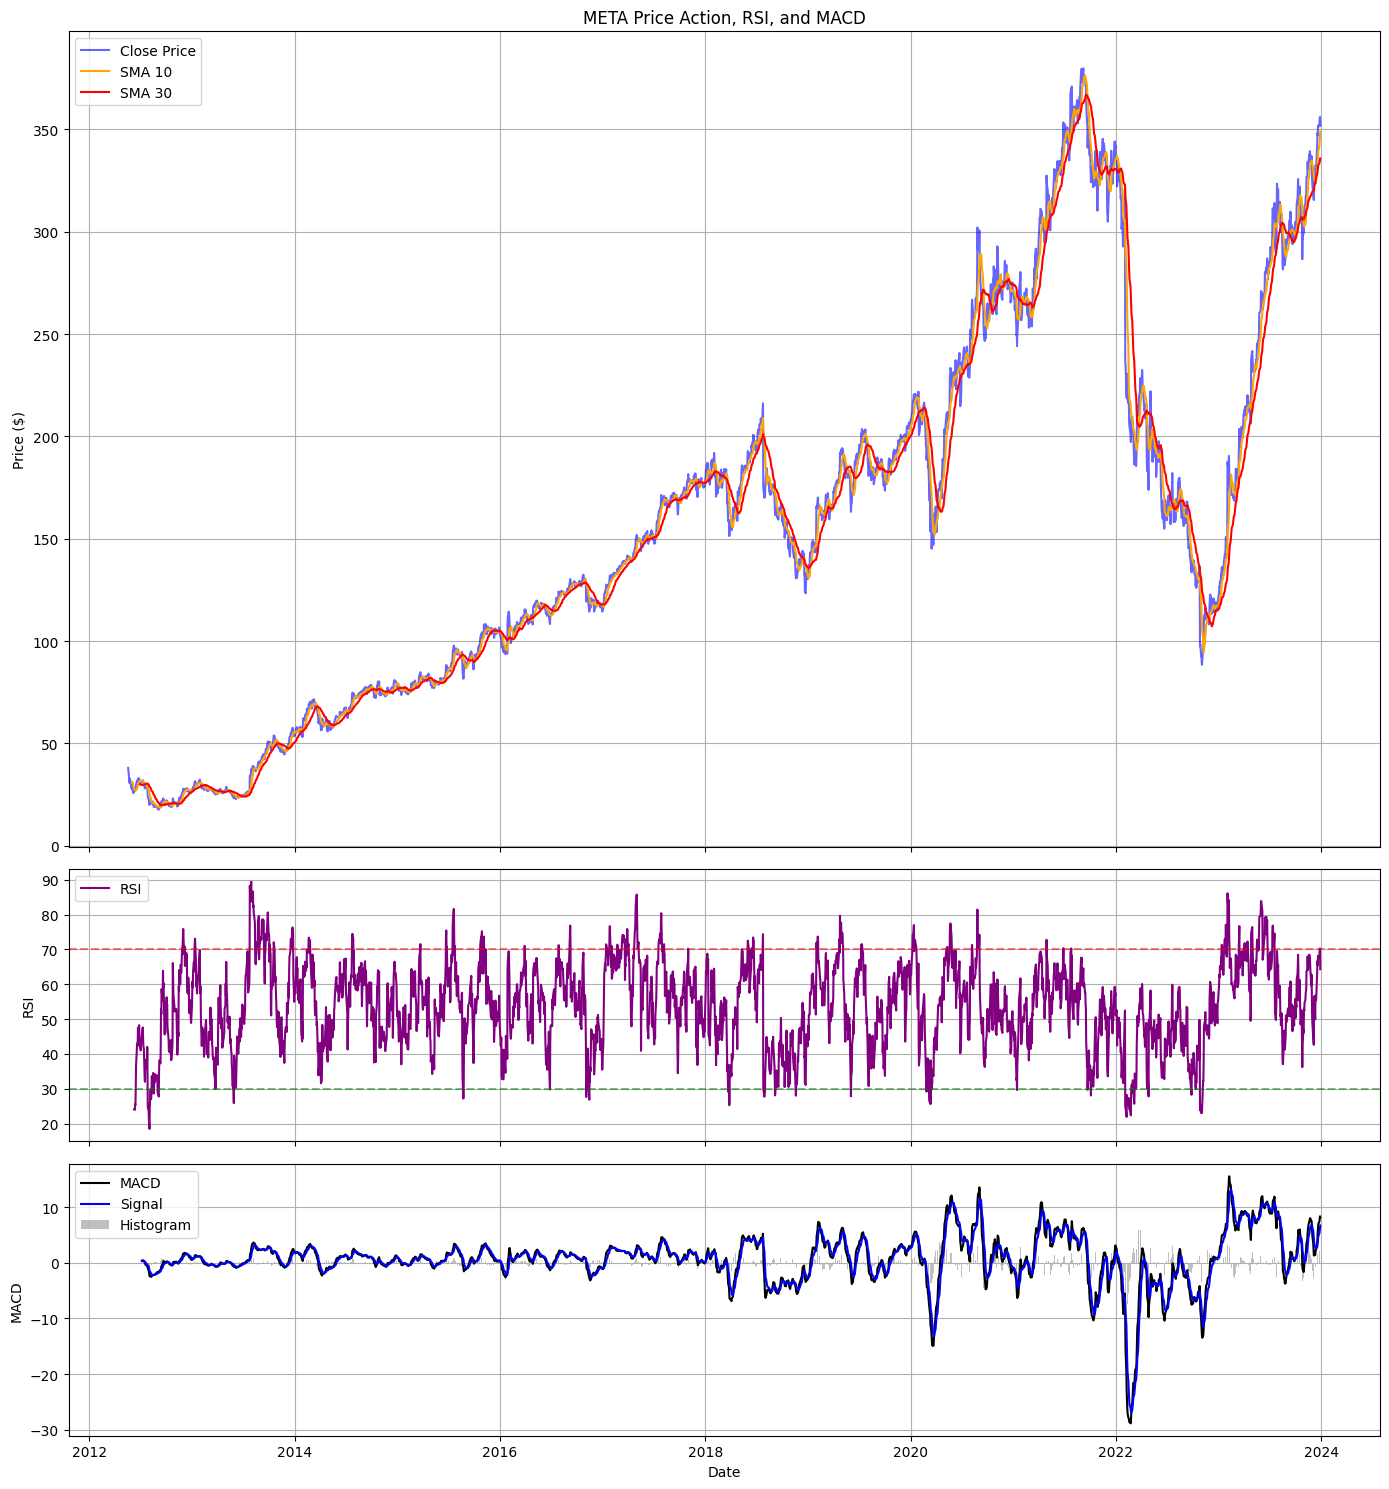

In [52]:
import matplotlib.pyplot as plt

# Create a figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 15), sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})

# Panel 1: Close Price and Moving Averages
ax1.plot(meta_df['Close'], label='Close Price', color='blue', alpha=0.6)
ax1.plot(meta_df['SMA_10'], label='SMA 10', color='orange')
ax1.plot(meta_df['SMA_30'], label='SMA 30', color='red')
ax1.set_title('META Price Action, RSI, and MACD')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left')
ax1.grid(True)

# Panel 2: RSI
ax2.plot(meta_df['RSI'], label='RSI', color='purple')
ax2.axhline(70, linestyle='--', alpha=0.5, color='red')
ax2.axhline(30, linestyle='--', alpha=0.5, color='green')
ax2.set_ylabel('RSI')
ax2.legend(loc='upper left')
ax2.grid(True)

# Panel 3: MACD
ax3.plot(meta_df['MACD'], label='MACD', color='black')
ax3.plot(meta_df['MACD_Signal'], label='Signal', color='blue')
ax3.bar(meta_df.index, meta_df['MACD_Hist'], label='Histogram', color='gray', alpha=0.5)
ax3.set_ylabel('MACD')
ax3.set_xlabel('Date')
ax3.legend(loc='upper left')
ax3.grid(True)

plt.tight_layout()
plt.show()

#### Plot Daily Returns and Historical Volatility

##### META Daily Returns Plot

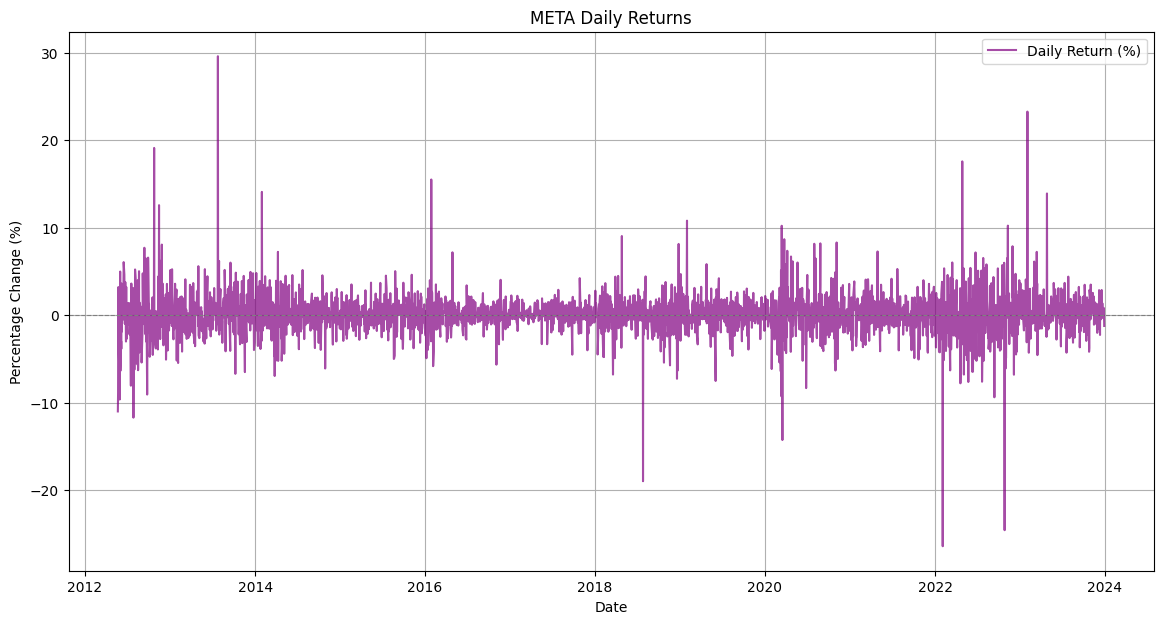

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(meta_df['Daily_Return'], label='Daily Return (%)', color='purple', alpha=0.7)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('META Daily Returns')
plt.xlabel('Date')
plt.ylabel('Percentage Change (%)')
plt.legend()
plt.grid(True)
plt.show()

##### META 20-Day Historical Volatility Plot

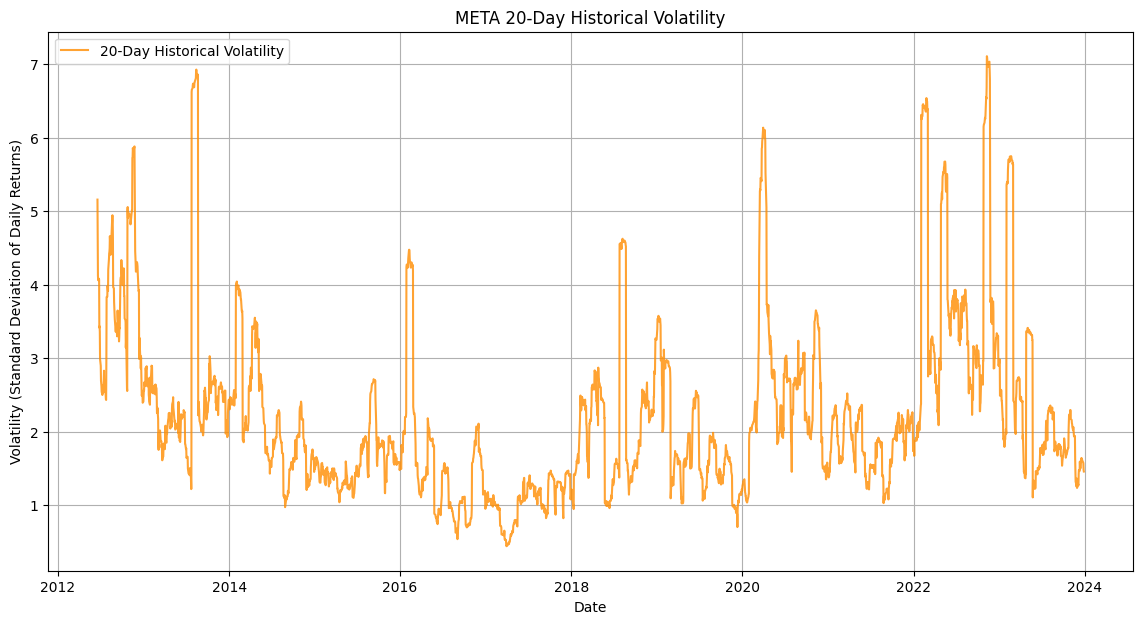

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(meta_df['Volatility_20_Day'], label='20-Day Historical Volatility', color='darkorange', alpha=0.8)
plt.title('META 20-Day Historical Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.legend()
plt.grid(True)
plt.show()

### Insights from Visualizations:

1.  **META Daily Returns Plot**:
    *   **Observation**: The plot shows frequent fluctuations around the zero line, indicating that daily price changes are common. There are periods of higher volatility (larger spikes, both positive and negative) and periods of relative calm.
    *   **Interpretation**: The stock exhibits typical market behavior, with daily gains and losses. The magnitude of these changes is key. Large positive spikes might correspond to positive news (e.g., strong earnings report, new product launch), while large negative spikes could be due to adverse events (e.g., market downturn, negative company news).
    *   **Actionable Insight**: For short-term traders, these fluctuations represent opportunities. For long-term investors, the overall trend and the frequency/magnitude of extreme movements are more important than individual daily wiggles.

2.  **META 20-Day Historical Volatility Plot**:
    *   **Observation**: This plot clearly illustrates periods where the 20-day rolling volatility is high and periods where it's low. Peaks in the volatility line suggest times of increased market uncertainty or rapid price swings, while troughs indicate more stable price action.
    *   **Interpretation**: Higher volatility means higher risk. When the volatility line is climbing, it implies that Meta's stock price is becoming more unpredictable, potentially offering larger gains but also exposing investors to greater potential losses. Conversely, low volatility suggests a more stable and predictable price environment.
    *   **Actionable Insight**: Periods of rising volatility might warrant caution for risk-averse investors or suggest opportunities for those employing volatility-based strategies. Conversely, periods of low volatility can lead to complacency, but also might precede a significant move. Understanding these trends helps in adjusting risk exposure and managing expectations.